In [1]:
import warnings
warnings.filterwarnings("ignore")

import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as sp_stats
from scipy.stats import binomtest, mannwhitneyu, fisher_exact, kruskal
from IPython.display import display, HTML, Markdown

# ── Database connection ──
DB_PATH = "C:/Users/scgee/OneDrive/Documents/Projects/PatientPunk/patientpunk.db"
conn = sqlite3.connect(DB_PATH)

# ── Sentiment mapping ──
SENTIMENT_SCORE = {"positive": 1.0, "mixed": 0.5, "neutral": 0.0, "negative": -1.0}

def to_numeric(s):
    """Convert sentiment string to numeric score."""
    return SENTIMENT_SCORE.get(s, 0.0)

def classify_outcome(avg_score):
    """Classify user-level average into outcome category."""
    if avg_score > 0.7:
        return "positive"
    elif avg_score < -0.3:
        return "negative"
    return "mixed/neutral"

def wilson_ci(k, n, z=1.96):
    """Wilson score confidence interval for a proportion."""
    if n == 0:
        return 0.0, 0.0
    p = k / n
    denom = 1 + z**2 / n
    center = (p + z**2 / (2 * n)) / denom
    margin = z * np.sqrt((p * (1 - p) + z**2 / (4 * n)) / n) / denom
    return max(0, center - margin), min(1, center + margin)

def nnt(treatment_rate, baseline_rate):
    """Number needed to treat. Returns None if rates are equal or inverted."""
    diff = treatment_rate - baseline_rate
    if diff <= 0:
        return None
    return round(1 / diff, 1)

# ── Chart defaults ──
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11

# ── Filtering sets ──
GENERIC_TERMS = {
    "supplements", "medication", "treatment", "therapy", "drug", "drugs",
    "vitamin", "prescription", "pill", "pills", "dosage", "dose",
}

# Colors
COLORS = {"positive": "#2ecc71", "mixed/neutral": "#95a5a6", "negative": "#e74c3c"}


# Sentiment reliability — can we run one cheap model at scale?

The roster ⑦ notebook established sentiment is *consistent* (within-model α 0.94) but only *moderately* agreed across models (panel α 0.64). This notebook asks the three questions that actually decide the production model choice:

1. **Where does each model sit?** Models differ systematically in how positive they are — so the choice of production model shifts the measured 'helped' rate.
2. **Where do models disagree?** The 0.64 α is real, but is it on the *effectiveness direction* (helped vs hurt) or the fuzzy *neutral boundary*? That decides whether the disagreement matters.
3. **Is one cheap model stable enough at scale?** DeepSeek Flash (the candidate) over 500 pairs × 5 repeats — item-level *and* aggregate.

*All against Polina (116 human labels) as a screen — she shares the prompt rubric, so this is agreement, not correctness; the permutation null is the separate is-it-drug-conditional check.*

In [2]:

import json
import numpy as np
from collections import Counter, defaultdict
from itertools import combinations
DV = r"C:/Users/scgee/OneDrive/Documents/Projects/PatientPunk/data/validation"
d = json.load(open(DV + "/j78_classify_runs.json", encoding="utf-8"))
R = d["results"]
POL = {(p["sample_id"], p["drug"]): p.get("sentiment") for p in d["polina"]}
SH = lambda m: m.split("/")[-1]
LAB = lambda m: m.split("/")[0]
DS = "deepseek/deepseek-v4-flash"
DIRB = {"positive": "+", "negative": "-", "neutral": "0", "mixed": "0"}
CATS = ["positive", "negative", "neutral", "mixed"]
SCOL = {"positive": "#27ae60", "negative": "#c0392b", "neutral": "#7f8c8d", "mixed": "#f39c12", "PARSE_FAIL": "#2c3e50"}
def mode(xs):
    xs = [x for x in xs if x]
    return Counter(xs).most_common(1)[0][0] if xs else None
# per-model modal call over the 3 repeats (denoised "which sentiment")
byk = defaultdict(list)
for r in R:
    if not r["parse_failed"] and r["sentiment"]:
        byk[(r["model"], r["sample_id"], r["drug"])].append(r["sentiment"])
call = {k: mode(v) for k, v in byk.items()}
MODELS = sorted({k[0] for k in call})
ITEMS = sorted({(k[1], k[2]) for k in call})
display(Markdown(f"*(loaded — {len(MODELS)} models × {len(ITEMS)} (post,drug) pairs × 3 repeats; "
 f"Polina reference {len(POL)} labels; production candidate = deepseek-v4-flash)*"))


*(loaded — 22 models × 116 (post,drug) pairs × 3 repeats; Polina reference 116 labels; production candidate = deepseek-v4-flash)*

## 1. Cross-model distribution — DeepSeek Flash is a *conservative* caller

The first thing that matters for a production switch: models don't just disagree at the margin, they sit at systematically different positive rates. Whichever model you pick sets the absolute 'helped' level, so its numbers aren't comparable to another model's.

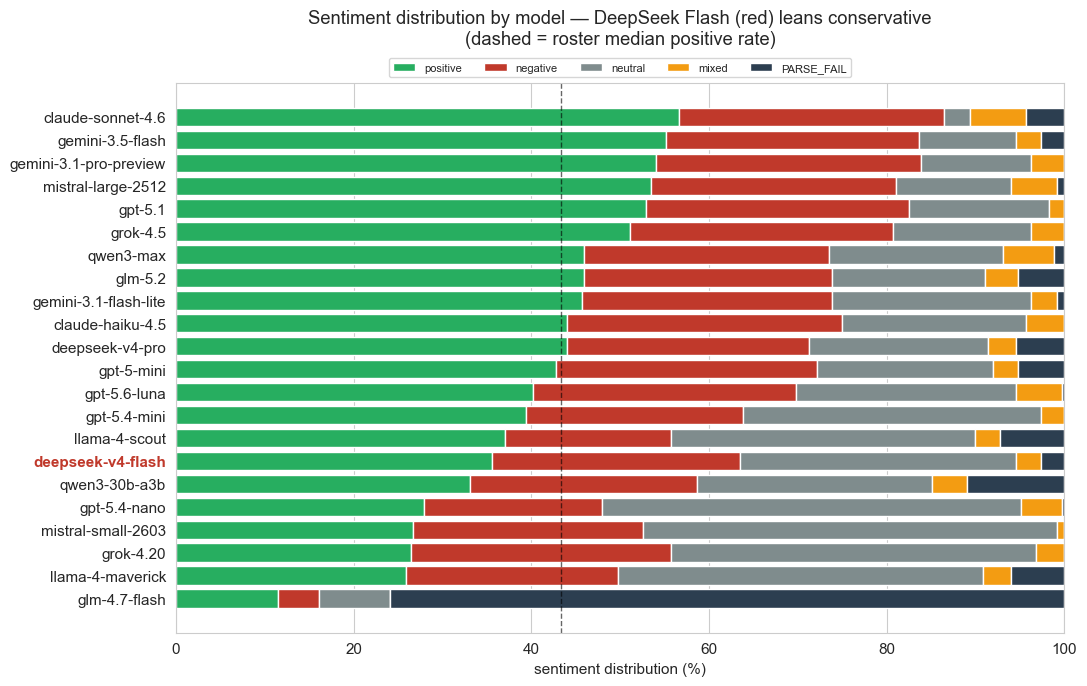

**DeepSeek Flash: 36% positive (roster median 43%), 31% neutral, 3% parse-fail** — it sits in the *cautious* cluster (less positive, more neutral), well below the frontier models (Sonnet 57%, Gemini-Pro 54%). **Consequence:** switching production from a Sonnet-based pipeline to DeepSeek Flash drops the measured positive rate ~20 points on identical posts. That's fine *if one model is held fixed across the whole corpus* (relative comparisons stay valid) — but its absolute rates are NOT comparable to the Sonnet-based published numbers. Conservatism is the SAFE direction re: the positive over-call concern.

In [3]:

by = defaultdict(Counter)
for r in R: by[r["model"]][r["sentiment"] if r["sentiment"] else "PARSE_FAIL"] += 1
cats = ["positive","negative","neutral","mixed","PARSE_FAIL"]
rows = []
for m in by:
    t = sum(by[m].values()); rows.append((SH(m), [by[m][c]/t*100 for c in cats]))
rows.sort(key=lambda x: -x[1][0])
names = [r[0] for r in rows]
fig, ax = plt.subplots(figsize=(11, 7)); left = np.zeros(len(rows))
for i, c in enumerate(cats):
    vals = np.array([r[1][i] for r in rows])
    ax.barh(names, vals, left=left, color=SCOL[c], label=c); left += vals
ax.invert_yaxis()
for lbl in ax.get_yticklabels():
    if lbl.get_text() == "deepseek-v4-flash": lbl.set_color("#c0392b"); lbl.set_fontweight("bold")
med_pos = np.median([r[1][0] for r in rows])
ax.axvline(med_pos, ls="--", color="k", lw=1, alpha=0.6)
ax.set_xlabel("sentiment distribution (%)"); ax.set_xlim(0, 100)
ax.legend(ncol=5, fontsize=8, loc="lower center", bbox_to_anchor=(0.5, 1.0))
ax.set_title("Sentiment distribution by model — DeepSeek Flash (red) leans conservative\n(dashed = roster median positive rate)", pad=28)
fig.tight_layout(); plt.show()
ds = by[DS]; dt = sum(ds.values())
allpos = [by[m]["positive"]/sum(by[m].values()) for m in by]
display(Markdown(
 f"**DeepSeek Flash: {ds['positive']/dt:.0%} positive (roster median {med_pos:.0f}%), {ds['neutral']/dt:.0%} neutral, "
 f"{ds['PARSE_FAIL']/dt:.0%} parse-fail** — it sits in the *cautious* cluster (less positive, more neutral), well "
 f"below the frontier models (Sonnet 57%, Gemini-Pro 54%). **Consequence:** switching production from a "
 f"Sonnet-based pipeline to DeepSeek Flash drops the measured positive rate ~20 points on identical posts. That's "
 f"fine *if one model is held fixed across the whole corpus* (relative comparisons stay valid) — but its absolute "
 f"rates are NOT comparable to the Sonnet-based published numbers. Conservatism is the SAFE direction re: the "
 f"positive over-call concern."))


## 2. Between-model structure — the disagreement is the neutral boundary, not direction

Panel α 0.64 is genuine (a clean 4-class label, no Jaccard artifact). But *where* models split decides whether it matters: a `positive↔negative` flip corrupts the effectiveness call; a `neutral↔weak-positive` flip is just granularity on the fuzzy middle.

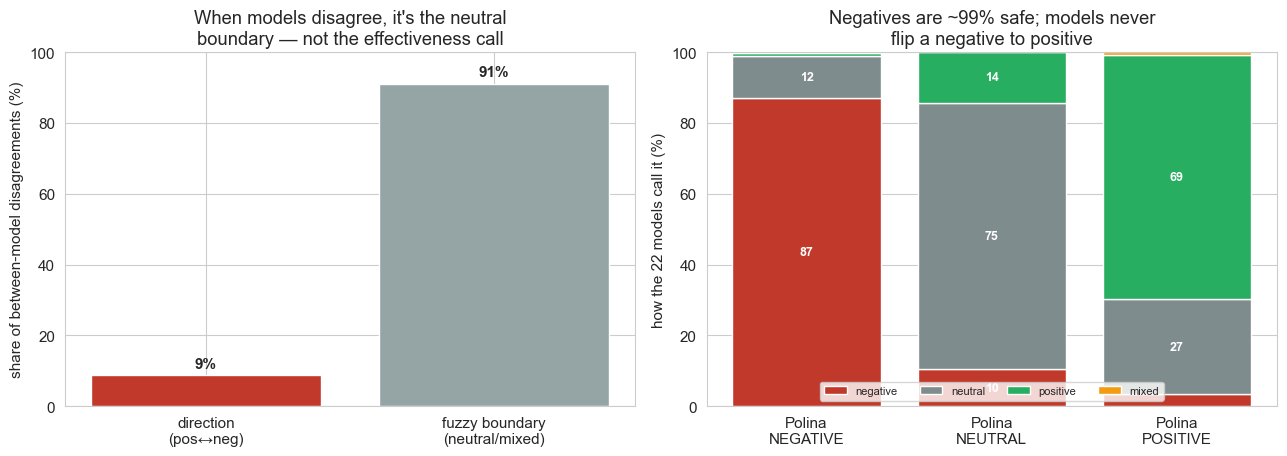

**91% of the disagreement is the neutral boundary; only 9% is pos↔neg.** On Polina-negative items the models say negative 87% / neutral 12% / **positive 1%** — they essentially never flip a negative to positive. And there's **no lab structure** (same-lab agree 78% vs cross-lab 76%, a +1pt gap) — unlike the ⑪ golds, sentiment disagreement is item-driven, not vendor-driven. **So the effectiveness direction is robust; the fragility lives entirely in weak-positive-vs-neutral.**

In [4]:

# pairwise disagreement confusion
pair_conf = Counter(); n_pairs = n_dis = 0
for (s, dr) in ITEMS:
    present = [(m, call[(m, s, dr)]) for m in MODELS if (m, s, dr) in call]
    for (ma, ca), (mb, cb) in combinations(present, 2):
        n_pairs += 1
        if ca != cb: n_dis += 1; pair_conf[tuple(sorted((ca, cb)))] += 1
hard = pair_conf[("negative", "positive")]; boundary = n_dis - hard
# directional reliability: model distribution conditioned on Polina label
def dist_when(label):
    c = Counter()
    for (s, dr) in ITEMS:
        if POL.get((s, dr)) != label: continue
        for m in MODELS:
            v = call.get((m, s, dr));
            if v: c[v] += 1
    t = sum(c.values()); return ({k: c[k]/t for k in CATS} if t else {}), t
fig, ax = plt.subplots(1, 2, figsize=(13, 4.7))
ax[0].bar(["direction\n(pos↔neg)", "fuzzy boundary\n(neutral/mixed)"],
          [hard/n_dis*100, boundary/n_dis*100], color=["#c0392b", "#95a5a6"])
for i, v in enumerate([hard/n_dis, boundary/n_dis]): ax[0].text(i, v*100+2, f"{v:.0%}", ha="center", fontweight="bold")
ax[0].set_ylabel("share of between-model disagreements (%)"); ax[0].set_ylim(0, 100)
ax[0].set_title("When models disagree, it's the neutral\nboundary — not the effectiveness call")
labels = ["Polina\nNEGATIVE", "Polina\nNEUTRAL", "Polina\nPOSITIVE"]
dists = [dist_when("negative")[0], dist_when("neutral")[0], dist_when("positive")[0]]
bottoms = np.zeros(3)
for c in ["negative","neutral","positive","mixed"]:
    vals = np.array([dd.get(c, 0)*100 for dd in dists])
    ax[1].bar(labels, vals, bottom=bottoms, color=SCOL[c], label=c)
    for i, (v, b) in enumerate(zip(vals, bottoms)):
        if v > 6: ax[1].text(i, b+v/2, f"{v:.0f}", ha="center", va="center", color="white", fontsize=9, fontweight="bold")
    bottoms += vals
ax[1].set_ylabel("how the 22 models call it (%)"); ax[1].set_ylim(0, 100)
ax[1].legend(fontsize=8, loc="lower center", ncol=4); ax[1].set_title("Negatives are ~99% safe; models never\nflip a negative to positive")
fig.tight_layout(); plt.show()
on_neg = dist_when("negative")[0]
# same-lab vs cross-lab
sa = st = ca = ct = 0
for (s, dr) in ITEMS:
    present = [(m, call[(m, s, dr)]) for m in MODELS if (m, s, dr) in call]
    for (ma, va), (mb, vb) in combinations(present, 2):
        if LAB(ma) == LAB(mb): st += 1; sa += (va == vb)
        else: ct += 1; ca += (va == vb)
display(Markdown(
 f"**{boundary/n_dis:.0%} of the disagreement is the neutral boundary; only {hard/n_dis:.0%} is pos↔neg.** "
 f"On Polina-negative items the models say negative {on_neg.get('negative',0):.0%} / neutral "
 f"{on_neg.get('neutral',0):.0%} / **positive {on_neg.get('positive',0):.0%}** — they essentially never flip a "
 f"negative to positive. And there's **no lab structure** (same-lab agree {sa/st:.0%} vs cross-lab {ca/ct:.0%}, "
 f"a +{(sa/st-ca/ct)*100:.0f}pt gap) — unlike the ⑪ golds, sentiment disagreement is item-driven, not vendor-driven. "
 f"**So the effectiveness direction is robust; the fragility lives entirely in weak-positive-vs-neutral.**"))


## 3. Within-model stability at scale — DeepSeek Flash, 500 pairs × 5 runs

The production question: at temperature 0, does one cheap model return the same answer run-to-run? Item-level and aggregate give *different* answers, and both matter.

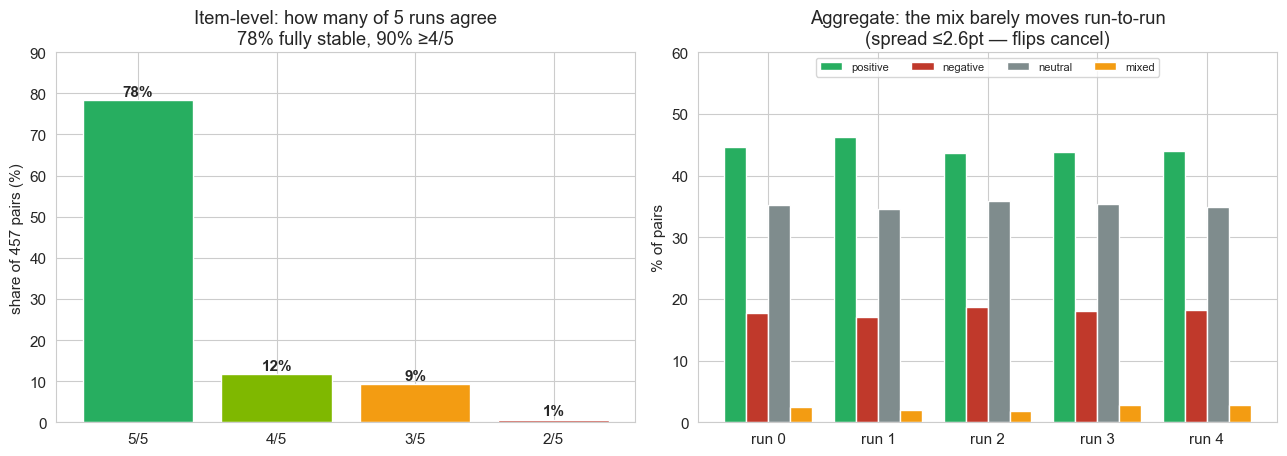

- **Item-level: moderate.** 78% of pairs identical across all 5 runs, 89% mean pairwise agreement — so ~11% of individual calls wobble at temp 0 (plausibly MoE backend nondeterminism).
- **The wobble is the fuzzy boundary, not the call:** of 99 unstable pairs, only **7 (1.5% of all pairs)** ever flip pos↔neg. The 'did it help' call is stable on ~98.5% of pairs.
- **Aggregate: rock-stable.** Positive stays within **2.6pt** across the 5 runs (negative 1.5pt, neutral 1.2pt) — the item flips cancel out.

In [5]:

sd = json.load(open(DV + "/j7_ds_stability.json", encoding="utf-8"))
SR = [r for r in sd["results"] if not r["parse_failed"] and r["sentiment"]]
K = sd["manifest"]["k"]
byp = defaultdict(dict)
for r in SR: byp[(r["sample_id"], r["drug"])][r["run"]] = r["sentiment"]
full = [p for p, v in byp.items() if len(v) == K]
ident = sum(1 for p in full if len(set(byp[p].values())) == 1)
modal = Counter(Counter(byp[p].values()).most_common(1)[0][1] for p in full)
unstable = [p for p in full if len(set(byp[p].values())) > 1]
dirflip = sum(1 for p in unstable if "+" in {DIRB[s] for s in byp[p].values()} and "-" in {DIRB[s] for s in byp[p].values()})
per_run = {k: Counter() for k in range(K)}
for r in SR: per_run[r["run"]][r["sentiment"]] += 1
rundist = {k: {c: per_run[k][c]/sum(per_run[k].values()) for c in CATS} for k in range(K)}
spread = {c: max(rundist[k][c] for k in range(K)) - min(rundist[k][c] for k in range(K)) for c in CATS}
fig, ax = plt.subplots(1, 2, figsize=(13, 4.7))
order = [K, K-1, K-2, K-3]; tot = sum(modal.values())
vals = [modal.get(k, 0)/tot*100 for k in order]
ax[0].bar([f"{k}/{K}" for k in order], vals, color=["#27ae60", "#7fb800", "#f39c12", "#c0392b"])
for i, v in enumerate(vals): ax[0].text(i, v+1, f"{v:.0f}%", ha="center", fontweight="bold")
ax[0].set_ylabel(f"share of {len(full)} pairs (%)"); ax[0].set_ylim(0, 90)
ax[0].set_title(f"Item-level: how many of {K} runs agree\n{ident/len(full):.0%} fully stable, {(modal.get(K,0)+modal.get(K-1,0))/tot:.0%} ≥4/5")
x = np.arange(K); w = 0.2
for i, c in enumerate(CATS):
    ax[1].bar(x+(i-1.5)*w, [rundist[k][c]*100 for k in range(K)], w, color=SCOL[c], label=c)
ax[1].set_xticks(x); ax[1].set_xticklabels([f"run {k}" for k in range(K)]); ax[1].set_ylim(0, 60)
ax[1].set_ylabel("% of pairs"); ax[1].legend(fontsize=8, ncol=4, loc="upper center")
ax[1].set_title(f"Aggregate: the mix barely moves run-to-run\n(spread ≤{max(spread.values())*100:.1f}pt — flips cancel)")
fig.tight_layout(); plt.show()
pair_agree = np.mean([byp[p][a] == byp[p][b] for p in full for a, b in combinations(range(K), 2)])
display(Markdown(
 f"- **Item-level: moderate.** {ident/len(full):.0%} of pairs identical across all {K} runs, {pair_agree:.0%} mean "
 f"pairwise agreement — so ~{1-pair_agree:.0%} of individual calls wobble at temp 0 (plausibly MoE backend "
 f"nondeterminism).\n"
 f"- **The wobble is the fuzzy boundary, not the call:** of {len(unstable)} unstable pairs, only **{dirflip} "
 f"({dirflip/len(full):.1%} of all pairs)** ever flip pos↔neg. The 'did it help' call is stable on "
 f"~{1-dirflip/len(full):.1%} of pairs.\n"
 f"- **Aggregate: rock-stable.** Positive stays within **{spread['positive']*100:.1f}pt** across the {K} runs "
 f"(negative {spread['negative']*100:.1f}pt, neutral {spread['neutral']*100:.1f}pt) — the item flips cancel out."))


## 4. Verdict — how to run it

In [6]:

display(Markdown(
 "**DeepSeek Flash is usable for a clustering study, with four conditions** — the two levels of "
 "reproducibility give opposite answers, and both are actionable:\n\n"
 "1. **Fine for aggregate rates (what clustering consumes).** The distribution is stable to ~2 points run-to-run "
 "and the effectiveness *direction* is stable on ~98% of posts. This is the level that feeds clustering.\n"
 "2. **NOT byte-reproducible per-post.** ~1-in-5 individual labels change on re-run, so don't rely on 'temp 0 = "
 "deterministic replay' (the C1 gate) for this model — **freeze the classified output as a versioned artifact** "
 "rather than assuming you can regenerate it identically.\n"
 "3. **Hold ONE model fixed across the whole corpus.** Its absolute positive rate is ~20pt below the frontier "
 "models (§1), so never mix models or compare to Sonnet-based numbers.\n"
 "4. **Cluster on DIRECTION (helped / no-effect / hurt), not the 4-class or a continuous score.** Both the "
 "between-model 0.64 α (§2, 91% neutral-boundary) and the within-model wobble (§3, 93% neutral-boundary) "
 "collapse to ~1-2% once you binarize — the fragility is entirely in the neutral boundary.\n\n"
 "**Still separate:** everything here is temp-0 variance and agreement-with-Polina, not *correctness*. Whether "
 "sentiment is drug-conditional at all is the **permutation null** (⑦ §5), still the highest-value open check "
 "before a large spend."))


**DeepSeek Flash is usable for a clustering study, with four conditions** — the two levels of reproducibility give opposite answers, and both are actionable:

1. **Fine for aggregate rates (what clustering consumes).** The distribution is stable to ~2 points run-to-run and the effectiveness *direction* is stable on ~98% of posts. This is the level that feeds clustering.
2. **NOT byte-reproducible per-post.** ~1-in-5 individual labels change on re-run, so don't rely on 'temp 0 = deterministic replay' (the C1 gate) for this model — **freeze the classified output as a versioned artifact** rather than assuming you can regenerate it identically.
3. **Hold ONE model fixed across the whole corpus.** Its absolute positive rate is ~20pt below the frontier models (§1), so never mix models or compare to Sonnet-based numbers.
4. **Cluster on DIRECTION (helped / no-effect / hurt), not the 4-class or a continuous score.** Both the between-model 0.64 α (§2, 91% neutral-boundary) and the within-model wobble (§3, 93% neutral-boundary) collapse to ~1-2% once you binarize — the fragility is entirely in the neutral boundary.

**Still separate:** everything here is temp-0 variance and agreement-with-Polina, not *correctness*. Whether sentiment is drug-conditional at all is the **permutation null** (⑦ §5), still the highest-value open check before a large spend.

## Limitations

- **Polina is a screen, not truth** — 116 labels, and her codebook was lifted from the pipeline prompt, so
  agreement measures spec-compliance, not correctness. Her `neutral` set is ~5 items, so that column is thin.
- **Two different samples.** §1–2 use the 116-pair Polina set; §3 uses a larger 500-pair set (personal-use-first
  from the 300 IRR frame), which has a different base rate — so compare *stability* across sections, not absolute
  levels (§3 positive 44% vs §1 36% is sample composition, not a model change).
- **Within-model wobble is temp-0 run-to-run variance**, likely MoE backend nondeterminism — it says nothing about
  whether a call is *right*. Correctness is the permutation-null / vs-gold question, out of scope here.
- **Distribution ≠ effectiveness.** A model's positive rate reflects its calibration + the sample, not ground-truth
  drug efficacy. Not medical advice.

In [7]:

m = d["manifest"]
prov = pd.DataFrame({"item": ["roster run", "candidate", "stability run", "reference", "metric", "skill"],
 "value": [f"{len(MODELS)} models × {len(ITEMS)} pairs × 3", "deepseek-v4-flash",
           f"500 pairs × {json.load(open(DV+'/j7_ds_stability.json',encoding='utf-8'))['manifest']['k']} (temp 0)",
           "human_coder_a (Polina), screen only", "distribution + disagreement structure + within-model stability",
           "research-assistant v2"]})
display(HTML("<b>Provenance</b>" + prov.to_html(index=False)))
display(HTML('<div style="font-size:1.15em;font-weight:bold;font-style:italic;margin-top:1em">'
             'Measures sentiment reliability against a human screen, not treatment effects. Not medical advice.</div>'))


item,value
roster run,22 models × 116 pairs × 3
candidate,deepseek-v4-flash
stability run,500 pairs × 5 (temp 0)
reference,"human_coder_a (Polina), screen only"
metric,distribution + disagreement structure + within-model stability
skill,research-assistant v2
